<a href="https://colab.research.google.com/github/nupihadi1234-tech/machine-learninproject/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Distribusi kelas sebelum SMOTE: Counter({0: 901, 1: 99})
Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):
Fitur_2: 0.11860019897866206
Fitur_3: 0.06878603593465271
Fitur_5: 0.07731131335837178
Fitur_8: 0.050482655781999855
Fitur_9: 0.2625049418105367
Fitur_10: 0.08958259568334655
Fitur_11: 0.06365230544114515
Fitur_15: 0.12578161860669113

Dimensi data pelatihan dengan fitur penting: (1000, 8)
      Fitur_2   Fitur_3   Fitur_5   Fitur_8   Fitur_9  Fitur_10  Fitur_11  \
0   -3.472520 -1.314199  0.642138  1.146301 -2.173112  2.765828 -1.821258   
1   -1.770842 -1.578851 -2.025230 -3.958705 -0.598147  1.018789  4.194233   
2   -2.051770  3.631998  1.674093  0.031633 -1.140149  2.069694  1.935251   
3   -1.608657 -0.735184 -1.753532 -2.897416 -0.830328  1.572469  5.334621   
4   -2.362885 -3.909120 -4.029843 -3.435229 -2.142380  2.332385  3.816539   
..        ...       ...       ...       ...       ...       ...       ...   
995 -0.017325  4.884411  3.033376  1.278882 -1

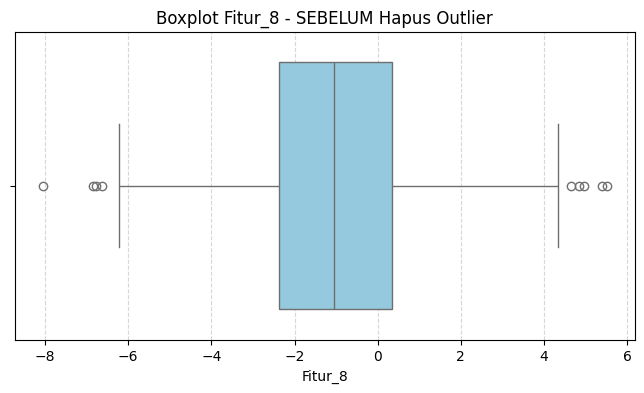

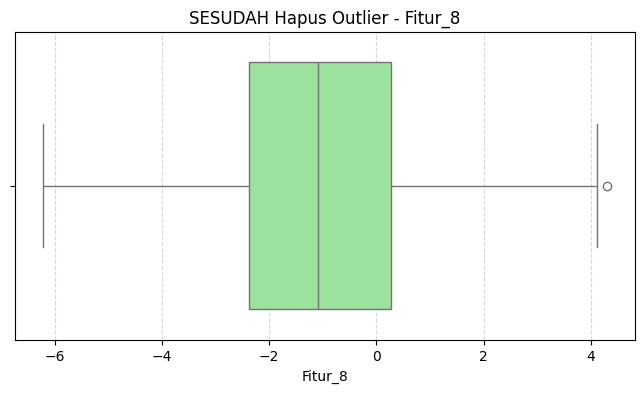

Jumlah data sebelum: 1000
Jumlah data sesudah: 915
Jumlah data yg dihapus: 85
Kolom kategorikal: ['Fitur_12', 'Fitur_13']
Bentuk data setelah encoding: (915, 17)
Target
0    847
1    847
Name: count, dtype: int64


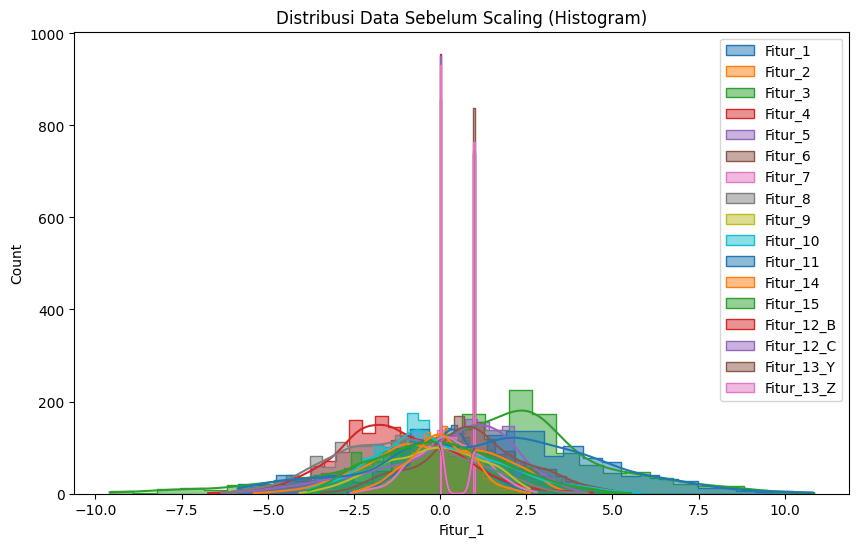

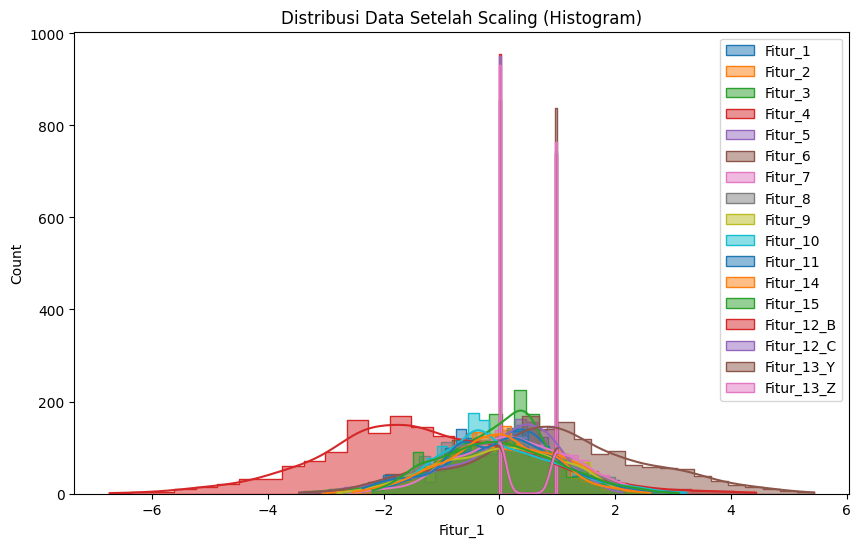

,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,Fitur_11,Fitur_14,Fitur_15,Fitur_12_B,Fitur_12_C,Fitur_13_Y,Fitur_13_Z
count,1694.000000,1694.000000,1.694000e+03,1694.000000,1694.000000,1694.000000,1694.000000,1.694000e+03,1694.000000,1.694000e+03,1.694000e+03,1694.000000,1694.000000,1694,1694,1694,1694
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,956,950,856,931
mean,0.112447,0.000000,1.677787e-17,-1.278099,0.000000,0.930386,0.241405,-4.194467e-18,0.000000,-3.355574e-17,-1.006672e-16,-0.032491,0.000000,NaN,NaN,NaN,NaN
std,0.918533,1.000295,1.000295e+00,1.742599,1.000295,1.573389,0.958242,1.000295e+00,1.000295,1.000295e+00,1.000295e+00,0.908965,1.000295,NaN,NaN,NaN,NaN
min,-2.680611,-3.056699,-3.374159e+00,-6.729950,-3.421958,-3.459413,-2.600121,-2.699901e+00,-2.796513,-2.150689e+00,-2.364828e+00,-2.527449,-2.191678,NaN,NaN,NaN,NaN
25%,-0.510678,-0.686433,-5.938996e-01,-2.389909,-0.578536,-0.026545,-0.427464,-7.285772e-01,-0.741149,-6.778696e-01,-6.595093e-01,-0.627982,-0.732015,NaN,NaN,NaN,NaN
50%,0.184853,0.011982,9.918713e-02,-1.413061,0.215369,0.896257,0.234211,1.819685e-02,0.060179,-1.809089e-01,4.437636e-02,-0.014507,-0.040773,NaN,NaN,NaN,NaN
75%,0.711490,0.783382,5.618295e-01,-0.125561,0.726086,1.911810,0.917321,7.008113e-01,0.752043,6.563338e-01,6.844615e-01,0.640167,0.694933,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=1000, n_features=15, n_informative=10, n_redundant=2,n_clusters_per_class=1, weights=[0.9], flip_y=0, random_state=42)

# Menyusun dataset menjadi DataFrame untuk kemudahan
df = pd.DataFrame(X, columns=[f'Fitur_{i}' for i in range(1, 16)])
df['Target'] = y

# Misalkan kita punya beberapa fitur kategorikal (simulasi fitur kategorikal)
df['Fitur_12'] = np.random.choice(['A', 'B', 'C'], size=1000)
df['Fitur_13'] = np.random.choice(['X', 'Y', 'Z'], size=1000)

df

# Memisahkan fitur dan target
X = df.drop('Target', axis=1)
y = df['Target']

# Melihat distribusi kelas
print("Distribusi kelas sebelum SMOTE:", Counter(y))

# ------------------- Embedded Methods -------------------
# Menggunakan Random Forest untuk mendapatkan fitur penting
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
X_integer = X.drop(['Fitur_12', 'Fitur_13'], axis=1)
rf_model.fit(X_integer, y)

# Mendapatkan fitur penting
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Menentukan ambang batas untuk fitur penting
threshold = 0.05  # Misalnya, ambang batas 5%
important_features_indices = [i for i in range(len(importances)) if importances[i] >= threshold]

# Menampilkan fitur penting beserta nilainya
print("Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):")
for i in important_features_indices:
    # Jika X asli berbentuk DataFrame, maka kita ambil nama kolom
    print(f"{X_integer.columns[i]}: {importances[i]}")

# Mendapatkan nama kolom penting berdasarkan importance
important_features = X_integer.columns[important_features_indices]

# Memindahkan fitur penting ke variabel baru
X_important = X_integer[important_features]  # Hanya fitur penting dari data pelatihan

# X_important sekarang berisi hanya fitur penting
print("\nDimensi data pelatihan dengan fitur penting:", X_important.shape)

X_Selected = pd.concat([X_important, X['Fitur_12']], axis=1)
X_Selected = pd.concat([X_Selected, X['Fitur_13']], axis=1)
X_Selected

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Melakukan Encoding untuk fitur 12
X_Selected['Fitur_12'] = label_encoder.fit_transform(X_Selected['Fitur_12'])
# print(label_encoder.inverse_transform(X_Selected[['Fitur_12']]))
# Melakukan Encoding untuk fitur 13
X_Selected['Fitur_13'] = label_encoder.fit_transform(X_Selected['Fitur_13'])
# print(label_encoder.inverse_transform(X_Selected[['Fitur_13']]))

print(X_Selected)

X_cleaned = X.copy()
y_cleaned = y.copy()

print("Sebelum IQR:", len(X_cleaned))

# 2. AMBIL KOLOM NUMERIK
numeric_columns = X_cleaned.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    # Melihat outlier dengan IQR (Interquartile Range)
    Q1 = X_cleaned[col].quantile(0.25)
    Q3 = X_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identifikasi outlier
    outliers = X_cleaned[(X_cleaned[col] < lower_bound) | (X_cleaned[col] > upper_bound)]

    # Menghapus outlier dari DataFrame
    X_cleaned = X_cleaned.drop(outliers.index)
    y_cleaned = y_cleaned.drop(outliers.index)

print("Sesudah IQR:", len(X_cleaned))

import matplotlib.pyplot as plt
import seaborn as sns

# 1. VISUALISASI FITUR_8 SEBELUM DIBERSIHIN
# Kita ambil dari X_important karena itu data aslinya sebelum di drop
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_important['Fitur_8'], color='skyblue')
plt.title('Boxplot Fitur_8 - SEBELUM Hapus Outlier')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 2. VISUALISASI FITUR_8 SETELAH DIBERSIHIN
# Kita ambil dari X_cleaned karena itu hasil dari kode IQR kamu
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_cleaned['Fitur_8'], color='lightgreen')
plt.title('SESUDAH Hapus Outlier - Fitur_8')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

print(f"Jumlah data sebelum: {len(X_important)}")
print(f"Jumlah data sesudah: {len(X_cleaned)}")
print(f"Jumlah data yg dihapus: {len(X_important) - len(X_cleaned)}")

# 1. CEK KOLOM KATEGORIKAL
cat_columns = X_cleaned.select_dtypes(include=['object', 'category']).columns
print("Kolom kategorikal:", list(cat_columns))

# 2. ONE-HOT ENCODING UNTUK KOLOM KATEGORIKAL
X_cleaned = pd.get_dummies(X_cleaned, columns=cat_columns, drop_first=True)

print("Bentuk data setelah encoding:", X_cleaned.shape)

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_cleaned, y_cleaned)

# Menampilkan distribusi kelas setelah SMOTE
print(pd.Series(y_resampled).value_counts())

# 1. Visualisasi distribusi data sebelum scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Sebelum Scaling (Histogram)')
plt.legend()
plt.show()

# Scaling: Standarisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler()

# Melakukan scaling pada fitur penting
X_resampled[important_features] = scaler.fit_transform(X_resampled[important_features])

# 1. Visualisasi distribusi data setelah scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Setelah Scaling (Histogram)')
plt.legend()
plt.show()

X_resampled.describe(include='all')